In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from tqdm import tqdm

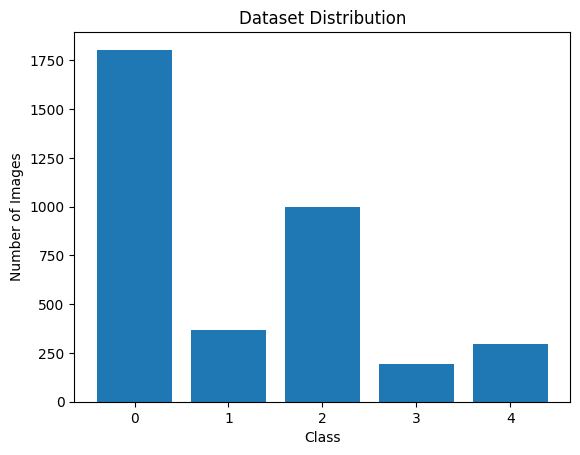

diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [10]:
df = pd.read_csv("../dataset/train.csv")

class_counts = df['diagnosis'].value_counts().sort_index()

plt.figure()
plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")
plt.show()

print(class_counts)

In [11]:
class DRDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['id_code'] + ".png"
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")
        label = int(self.df.iloc[idx]['diagnosis'])

        if self.transform:
            image = self.transform(image)

        return image, label

In [12]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [13]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['diagnosis'],
    random_state=42
)

train_dataset = DRDataset(train_df, "../dataset/train_images", transform)
val_dataset = DRDataset(val_df, "../dataset/train_images", transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 5)
model = model.to(device)

c:\Users\Sahil Kanojiya\Desktop\DiabeticRetinopathyProject\dr_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Sahil Kanojiya\Desktop\DiabeticRetinopathyProject\dr_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [16]:
epochs = 10

train_losses = []
val_losses = []
train_accs = []
val_accs = []
f1_scores = []

for epoch in range(epochs):

    # TRAIN
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_losses.append(train_loss / len(train_loader))
    train_accs.append(train_acc)

    # VALIDATION
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_acc)

    # F1 Score
    f1 = f1_score(all_labels, all_preds, average='weighted')
    f1_scores.append(f1)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_acc:.4f}")
    print(f"F1 Score: {f1:.4f}")

100%|██████████| 184/184 [08:35<00:00,  2.80s/it]



Epoch 1
Train Loss: 0.6664, Train Acc: 0.7504
Val Loss: 0.6649, Val Acc: 0.7776
F1 Score: 0.7694


100%|██████████| 184/184 [07:31<00:00,  2.45s/it]



Epoch 2
Train Loss: 0.4787, Train Acc: 0.8330
Val Loss: 0.5791, Val Acc: 0.7708
F1 Score: 0.7738


100%|██████████| 184/184 [07:32<00:00,  2.46s/it]


...


Epoch 8
Train Loss: 0.1433, Train Acc: 0.9495
Val Loss: 0.7055, Val Acc: 0.8158
F1 Score: 0.8038


100%|██████████| 184/184 [10:19<00:00,  3.37s/it]



Epoch 9
Train Loss: 0.1315, Train Acc: 0.9635
Val Loss: 0.8066, Val Acc: 0.8199
F1 Score: 0.8079


100%|██████████| 184/184 [07:14<00:00,  2.36s/it]



Epoch 10
Train Loss: 0.1220, Train Acc: 0.9594
Val Loss: 0.6754, Val Acc: 0.8213
F1 Score: 0.8165


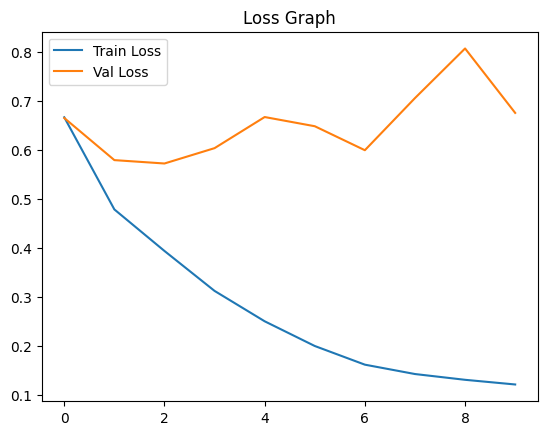

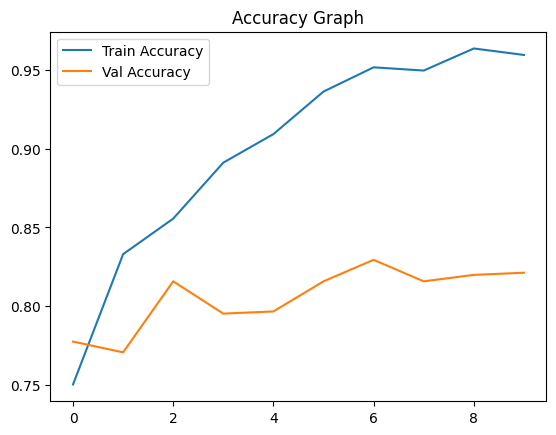

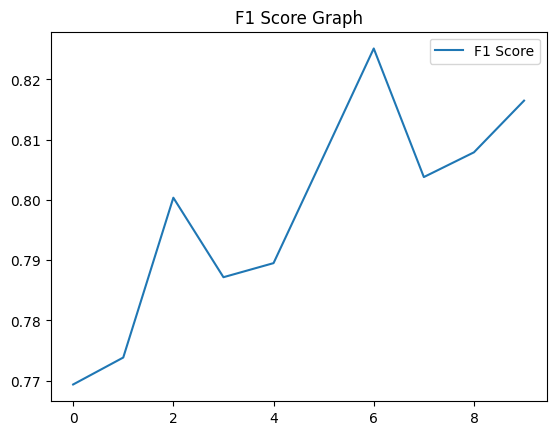

In [17]:
# Loss
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Graph")
plt.show()

# Accuracy
plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.legend()
plt.title("Accuracy Graph")
plt.show()

# F1 Score
plt.figure()
plt.plot(f1_scores, label="F1 Score")
plt.legend()
plt.title("F1 Score Graph")
plt.show()

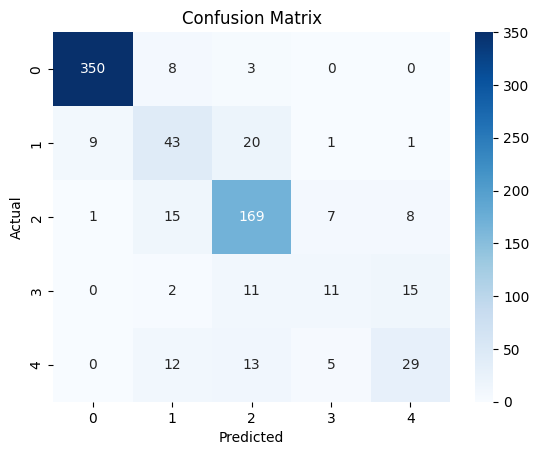

In [18]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       361
           1       0.54      0.58      0.56        74
           2       0.78      0.84      0.81       200
           3       0.46      0.28      0.35        39
           4       0.55      0.49      0.52        59

    accuracy                           0.82       733
   macro avg       0.66      0.63      0.64       733
weighted avg       0.81      0.82      0.82       733



In [20]:
torch.save(model.state_dict(), "../model/dr_model.pth")
print("Model Saved Successfully!")

Model Saved Successfully!
